# Proyecto Integrado de Ciencia de Datos
## Análisis de Netflix User Behavior Dataset

### Integrantes:
- Nombre : Johann Carrasco
- Nombre : Pablo Daza
- Nombre : Ricardo Ruiz

### Asignatura:
Programación para la Ciencia de Datos (SCY1101)

## 1. Introducción

En este proyecto se trabaja con un dataset de comportamiento de usuarios de Netflix.
El objetivo es limpiar, transformar y preparar los datos para obtener un conjunto de datos más útil

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
df = pd.read_csv("netflix_user_behavior_dataset.csv")
print("Dataset cargado correctamente")
df.head()


Dataset cargado correctamente


,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16.0,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14.0,No
2,U100002,32,Other,USA,25,Basic,15.99,paypal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41.0,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22.0,No
4,U100004,25,NaN,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54.0,No


In [3]:
# Dimensiones del dataset
df.shape

(50750, 20)

In [4]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50750 entries, 0 to 50749
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50648 non-null  object 
 1   age                        50750 non-null  int64  
 2   gender                     49992 non-null  object 
 3   country                    50145 non-null  object 
 4   account_age_months         50750 non-null  int64  
 5   subscription_type          50750 non-null  object 
 6   monthly_fee                50750 non-null  object 
 7   payment_method             49988 non-null  object 
 8   primary_device             50750 non-null  object 
 9   devices_used               50750 non-null  int64  
 10  favorite_genre             49983 non-null  object 
 11  avg_watch_time_minutes     50750 non-null  int64  
 12  watch_sessions_per_week    50750 non-null  int64  
 13  binge_watch_sessions       50750 non-null  int

In [5]:
# Estadísticas descriptivas
df.describe(include="all")

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
count,50648,50750.000000,49992,50145,50750.000000,50750,50750,49988,50750,50750.000000,49983,50750.000000,50750.000000,50750.000000,50750,49836.000000,50750.000000,50750,50141.000000,50750
unique,49758,NaN,6,16,NaN,6,12,8,8,NaN,14,NaN,NaN,NaN,209,NaN,NaN,292,NaN,4
top,U107244,NaN,Female,Spain,NaN,Standard,15.99,PayPal,Mobile,NaN,Thriller,NaN,NaN,NaN,49,NaN,NaN,72,NaN,No
freq,3,NaN,16443,5032,NaN,19835,16726,12235,12529,NaN,6232,NaN,NaN,NaN,770,NaN,NaN,560,NaN,39982
mean,NaN,41.076118,NaN,NaN,29.875507,NaN,NaN,NaN,NaN,2.007764,NaN,156.157340,10.036729,7.006857,NaN,3.005137,24.314798,NaN,30.482499,NaN
std,NaN,13.878957,NaN,NaN,17.048457,NaN,NaN,NaN,NaN,0.872838,NaN,92.056878,5.632410,4.335761,NaN,1.163642,14.472029,NaN,34.810251,NaN
min,NaN,5.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,-1.000000,0.000000,NaN,-10.000000,NaN
25%,NaN,29.000000,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,1.000000,NaN,82.000000,5.000000,3.000000,NaN,2.000000,12.000000,NaN,14.000000,NaN
50%,NaN,41.000000,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,2.000000,NaN,155.000000,10.000000,7.000000,NaN,3.000000,24.000000,NaN,29.000000,NaN
75%,NaN,53.000000,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,3.000000,NaN,228.000000,15.000000,11.000000,NaN,4.000000,37.000000,NaN,45.000000,NaN


In [6]:
# Revisar valores nulos
df.isnull().sum()

,0
user_id,102
age,0
gender,758
country,605
account_age_months,0
subscription_type,0
monthly_fee,0
payment_method,762
primary_device,0
devices_used,0


In [7]:
# Revisar duplicados
df.duplicated().sum()

np.int64(738)

### Observación inicial
En esta etapa se revisó la estructura general del dataset, incluyendo dimensiones, tipos de datos, valores nulos y duplicados.
Esto permite identificar problemas antes de comenzar la limpieza y transformación de los datos.

## 4. Limpieza de datos

En esta etapa se revisan posibles problemas de calidad del dataset, como valores nulos, filas duplicadas, valores atípicos y columnas que no aportan al análisis.
Aunque un dataset parezca ordenado, esta fase es importante para asegurar que el flujo sea profesional y reproducible.

In [8]:
# Eliminar columna que solo identifica al usuario
df = df.drop(columns=["user_id"])

print("Columna user_id eliminada correctamente")

Columna user_id eliminada correctamente


In [9]:
# Seleccionar columnas numéricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
columnas_numericas

Index(['age', 'account_age_months', 'devices_used', 'avg_watch_time_minutes',
       'watch_sessions_per_week', 'binge_watch_sessions', 'rating_given',
       'content_interactions', 'days_since_last_login'],
      dtype='object')

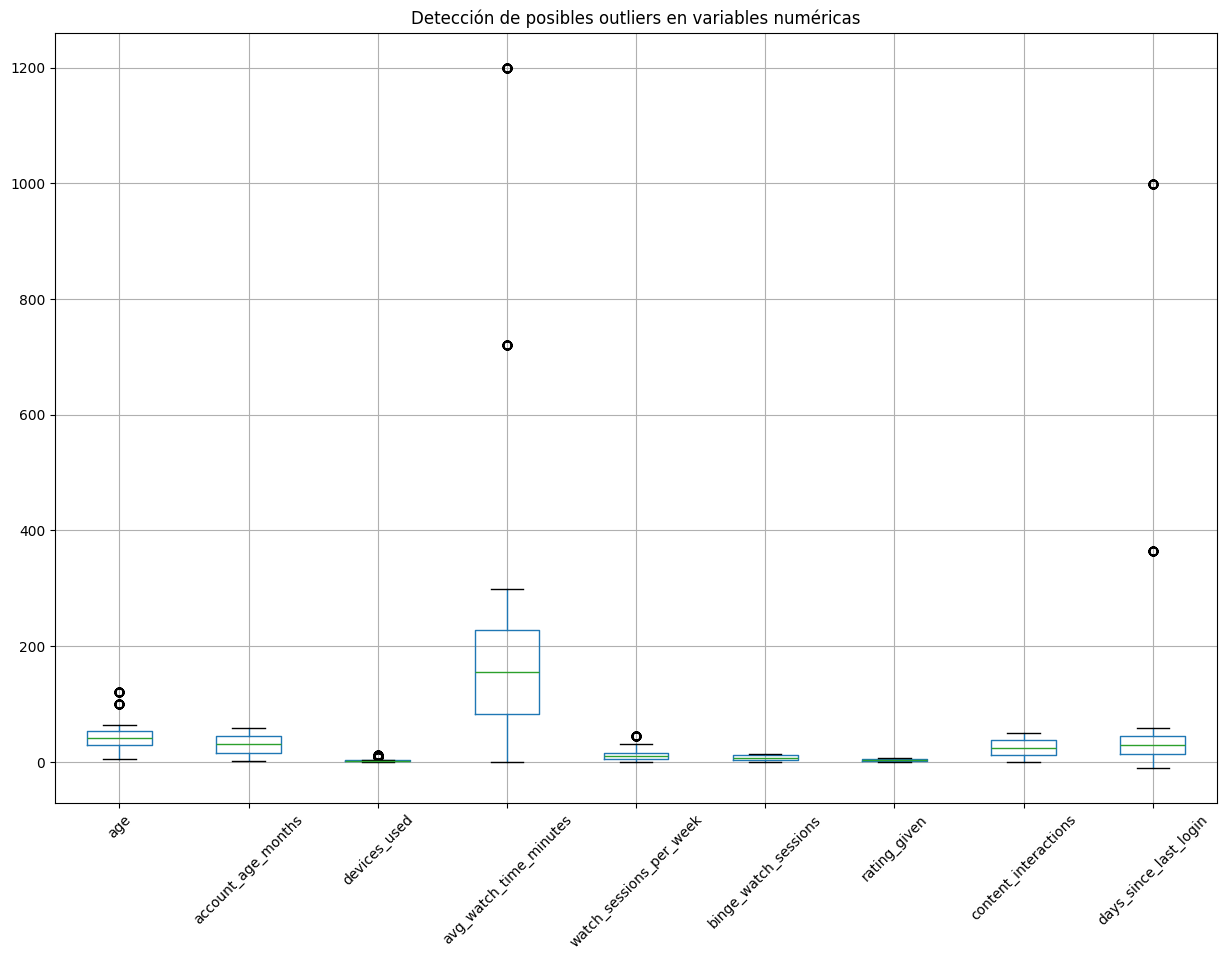

In [10]:
# Visualizar posibles outliers
plt.figure(figsize=(15, 10))
df[columnas_numericas].boxplot(rot=45)
plt.title("Detección de posibles outliers en variables numéricas")
plt.show()

In [11]:
# Resumen estadístico de variables numéricas
df[columnas_numericas].describe()

,age,account_age_months,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,rating_given,content_interactions,days_since_last_login
count,50750.000000,50750.000000,50750.000000,50750.000000,50750.000000,50750.000000,49836.000000,50750.000000,50141.000000
mean,41.076118,29.875507,2.007764,156.157340,10.036729,7.006857,3.005137,24.314798,30.482499
std,13.878957,17.048457,0.872838,92.056878,5.632410,4.335761,1.163642,14.472029,34.810251
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,-10.000000
25%,29.000000,15.000000,1.000000,82.000000,5.000000,3.000000,2.000000,12.000000,14.000000
50%,41.000000,30.000000,2.000000,155.000000,10.000000,7.000000,3.000000,24.000000,29.000000
75%,53.000000,45.000000,3.000000,228.000000,15.000000,11.000000,4.000000,37.000000,45.000000
max,120.000000,59.000000,12.000000,1200.000000,45.000000,14.000000,7.000000,49.000000,999.000000


In [12]:
# Crear copia del dataset limpio
df_limpio = df.copy()

print("Limpieza básica completada")

Limpieza básica completada


### Sobre la limpieza

Se revisaron valores nulos, duplicados y outliers en el dataset.
No se detectaron problemas graves de nulos o duplicados, pero igualmente se documentó su revisión como parte del flujo de limpieza

In [ ]:
# Crear nueva columna de actividad del usuario
df_limpio["nivel_actividad"] = pd.cut(
    df_limpio["watch_sessions_per_week"],
    bins=[0, 6, 12, 20],
    labels=["Baja", "Media", "Alta"]
)

df_limpio[["watch_sessions_per_week", "nivel_actividad"]].head()

,watch_sessions_per_week,nivel_actividad
0,17,Alta
1,15,Alta
2,6,Baja
3,4,Baja
4,15,Alta


In [13]:
# Separar variables predictoras y variable objetivo
X = df_limpio.drop(columns=["churned"])
y = df_limpio["churned"]

print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (50750, 18)
Variable objetivo: (50750,)


In [14]:
# Identificar columnas numéricas y categóricas
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Columnas numéricas:")
print(columnas_numericas)

print("\nColumnas categóricas:")
print(columnas_categoricas)

Columnas numéricas:
['age', 'account_age_months', 'devices_used', 'avg_watch_time_minutes', 'watch_sessions_per_week', 'binge_watch_sessions', 'rating_given', 'content_interactions', 'days_since_last_login']

Columnas categóricas:
['gender', 'country', 'subscription_type', 'monthly_fee', 'payment_method', 'primary_device', 'favorite_genre', 'completion_rate', 'recommendation_click_rate']


In [15]:
# Crear transformador de columnas
preprocesador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), columnas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
])

print("Preprocesador creado correctamente")

Preprocesador creado correctamente


In [16]:
# Crear pipeline de preprocesamiento
pipeline_final = Pipeline(steps=[
    ("prep", preprocesador)
])

print("Pipeline creado correctamente")

Pipeline creado correctamente


In [17]:
# Aplicar transformación
X_transformado = pipeline_final.fit_transform(X)

print("Transformación completada")
print("Dimensión de la matriz transformada:", X_transformado.shape)

Transformación completada
Dimensión de la matriz transformada: (50750, 584)


## 6. Visualización final

En esta sección se presenta una visualización que resume una relación importante en el dataset.
Se analizará la relación entre el nivel de actividad del usuario y la variable churned, con el fin de observar si los usuarios menos activos presentan una mayor tendencia al abandono.

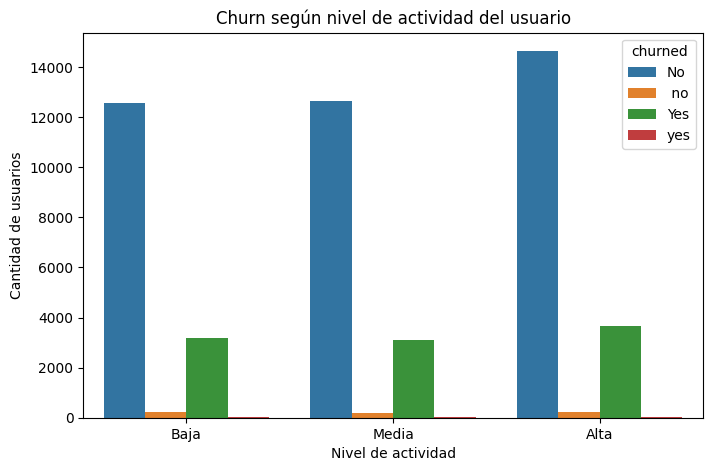

In [ ]:
# Gráfico de churn por nivel de actividad
plt.figure(figsize=(8, 5))
sns.countplot(data=df_limpio, x="nivel_actividad", hue="churned")
plt.title("Churn según nivel de actividad del usuario")
plt.xlabel("Nivel de actividad")
plt.ylabel("Cantidad de usuarios")
plt.show()

## 7. Conclusiones

En este proyecto se realizó la exploración, limpieza y transformación de un dataset de usuarios de Netflix.

Se revisaron nulos, duplicados y outliers, además de eliminar la columna user_id por no aportar al análisis.

Luego, se creó la variable nivel_activida y se aplicaron técnicas como StandardScaler, OneHotEncoder y Pipeline para preparar los datos de forma ordenada y reproducible.

In [ ]:
# Guardar dataset procesado
df_limpio.to_csv("netflix_limpio_transformado.csv", index=False)

print("Dataset procesado guardado correctamente")

Dataset procesado guardado correctamente
